# Optimized Gradient Method (OGM)

We consider a convex and L-smooth function f with a stationary minimizer x_star satisfying grad f(x_star) = 0. The initial condition is ||x_0 - x_star|| <= R, and the performance metric is f(x_N) - f(x_star).

Define theta_{-1} = 0. For a fixed horizon N,

$$
\theta_N = \frac{1}{2}\left(1 + \sqrt{8\theta_{N-1}^2 + 1}\right),
$$

and for 0 <= k < N,

$$
\theta_k = \frac{1}{2}\left(1 + \sqrt{4\theta_{k-1}^2 + 1}\right).
$$

The OGM iteration with fixed stepsize 1/L is

$$
\begin{aligned}
z_0 &= x_0,\\
y_k &= x_k - \frac{1}{L}\nabla f(x_k),\\
z_{k+1} &= z_k - \frac{2\theta_k}{L}\nabla f(x_k),\\
x_{k+1} &= \left(1 - \frac{1}{\theta_{k+1}}\right)y_k + \frac{1}{\theta_{k+1}}z_{k+1}.
\end{aligned}
$$

Block 1 numerical evidence suggests the candidate rate L R^2 / (2 theta_N^2).

## Proof Statement


### Theorem

Let $f$ be convex and $L$-smooth, and let $x_\star$ satisfy $\nabla f(x_\star)=0$. For the fixed-horizon OGM recurrence in this notebook, assume $\|x_0-x_\star\|\le R$. Let $\theta_{-1}=0$, let $\theta_k=\frac12(1+\sqrt{4\theta_{k-1}^2+1})$ for $0\le k<N$, and let $\theta_N=\frac12(1+\sqrt{8\theta_{N-1}^2+1})$.

For $1\le k<N$, define the Lyapunov certificate

$$
V_k =
\frac{2\theta_k^2}{\theta_N^2}\bigl(f(x_k)-f(x_\star)\bigr)
-\frac{L}{2\theta_N^2}\|x_0-x_\star\|^2
-\frac{\theta_k^2}{L\theta_N^2}\|\nabla f(x_k)\|^2
+\frac{L}{2\theta_N^2}\|z_{k+1}-x_\star\|^2.
$$

Then the final iterate satisfies

$$
f(x_N)-f(x_\star)\le \frac{L R^2}{2\theta_N^2}.
$$

### Proof outline

For a smooth convex interpolation residual, write

$$
I_f(u,v)=f(v)-f(u)+\langle \nabla f(v),u-v\rangle
+\frac{1}{2L}\|\nabla f(u)-\nabla f(v)\|^2\le 0.
$$

The base identity is

$$
V_1 =
\frac{2}{\theta_N^2} I_f(x_\star,x_0)
+\frac{2}{\theta_N^2} I_f(x_0,x_1)
+\frac{2\theta_1}{\theta_N^2} I_f(x_\star,x_1).
$$

For $1\le k<N-1$, using $\theta_{k+1}^2-\theta_{k+1}=\theta_k^2$,

$$
V_{k+1}-V_k =
\frac{2\theta_k^2}{\theta_N^2}I_f(x_k,x_{k+1})
+\frac{2\theta_{k+1}}{\theta_N^2}I_f(x_\star,x_{k+1})\le 0.
$$

Thus $V_k$ is nonincreasing under the chosen sign convention. The terminal certificate uses

$$
S =
\frac{L}{2\theta_N^2}
\left\|x_0-x_\star-\sum_{i=0}^{N-1}\frac{2\theta_i}{L}\nabla f(x_i)
-\frac{\theta_N}{L}\nabla f(x_N)\right\|^2\ge 0
$$

and the boundary identity

$$
\frac{L}{2\theta_N^2}\|x_0-x_\star\|^2
-\bigl(f(x_N)-f(x_\star)\bigr)
+V_N-S=0.
$$

Since $V_N\le V_0=0$ and $S\ge0$, the claimed bound follows.

In [19]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

import pepflow as pf  # noqa: E402
from examples_peppy.ogm import ogm_setup  # noqa: E402
from examples_peppy.ogm.ogm_setup import get_pep_setup, ogm_theta_sequence  # noqa: E402

## Function And Parameters

In [20]:
L = pf.Parameter("L")
R = pf.Parameter("R")
f = pf.SmoothConvexFunction(is_basis=True, tags=["f_notebook"], L=L)

c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:




## OGM PEP Setup

In [21]:
def notebook_theta_sequence(N):
    theta_prev = sp.S(0)
    theta = []
    for _ in range(int(N)):
        theta_k = sp.Rational(1, 2) * (1 + sp.sqrt(4 * theta_prev**2 + 1))
        theta.append(theta_k)
        theta_prev = theta_k
    theta.append(sp.Rational(1, 2) * (1 + sp.sqrt(8 * theta_prev**2 + 1)))
    return theta


def make_ctx_ogm_notebook(ctx_name, N):
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    z = x
    z.add_tag("z_0")
    f.set_stationary_point("x_star")
    theta = notebook_theta_sequence(N)

    for k in range(int(N)):
        grad_x = f.grad(x)
        y = x - (sp.S(1) / L) * grad_x
        y.add_tag(f"y_{k}")
        z = z - (sp.S(2) / L) * theta[k] * grad_x
        z.add_tag(f"z_{k + 1}")
        x = (1 - sp.S(1) / theta[k + 1]) * y + (sp.S(1) / theta[k + 1]) * z
        x.add_tag(f"x_{k + 1}")

    return ctx


def get_pep_setup_notebook(N, params):
    ctx = make_ctx_ogm_notebook(f"ctx_notebook_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(f(ctx[f"x_{N}"]) - f(ctx["x_star"]))
    return ctx, pb, f

## Numerical Evidence

N=1: PEP=0.1249989122, candidate=0.1250000000
N=2: PEP=0.0618918528, candidate=0.0618941824
N=3: PEP=0.0376920438, candidate=0.0376923972
N=4: PEP=0.0255836264, candidate=0.0255839420
N=5: PEP=0.0185869483, candidate=0.0185881367
N=6: PEP=0.0141553929, candidate=0.0141559659


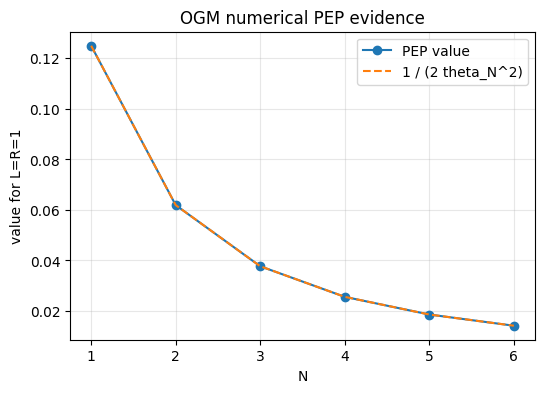

Note: Numerical PEP sweep completed for N=1..6. N=7 was attempted twice and exceeded the practical local solve window, so it is not included as a solved PEP value.


In [22]:
state_path = Path("examples_peppy/ogm/state/ogm_b1.json")
state = json.loads(state_path.read_text())
sweep = state["sweep_results"]
candidate = {row["N"]: row for row in state["candidate_rate_values"]}

for row in sweep:
    n = row["N"]
    print(
        f"N={n}: PEP={row['opt_value']:.10f}, "
        f"candidate={candidate[n]['rate_LR2_1']:.10f}"
    )

Ns = [row["N"] for row in sweep]
pep_values = [row["opt_value"] for row in sweep]
candidate_values = [candidate[n]["rate_LR2_1"] for n in Ns]

plt.figure(figsize=(6, 4))
plt.plot(Ns, pep_values, "o-", label="PEP value")
plt.plot(Ns, candidate_values, "--", label="1 / (2 theta_N^2)")
plt.xlabel("N")
plt.ylabel("value for L=R=1")
plt.title("OGM numerical PEP evidence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Note:", " ".join(state["notes"]))

## Dense And Relaxed Proof Solves

Block 2 solves the full PEP at N = 4 and then imposes the sparse interpolation pattern suggested by the dense dual certificate. The sparse relaxation preserves the optimum to the Block 2 tolerance.

In [23]:
b2_path = Path("examples_peppy/ogm/state/ogm_b2.json")
dense_path = Path("examples_peppy/ogm/state/ogm_dense.json")
relaxed_path = Path("examples_peppy/ogm/state/ogm_relaxed.json")

b2 = json.loads(b2_path.read_text())
dense = json.loads(dense_path.read_text())
relaxed = json.loads(relaxed_path.read_text())

print(f"N_verify = {b2['N_verify']}")
print(f"dense optimum  = {dense['opt_value']:.10f}")
print(f"relaxed optimum = {relaxed['opt_value']:.10f}")
print(
    f"candidate rate  = {b2['candidate_rate_values'][b2['N_verify'] - 1]['rate_LR2_1']:.10f}"
)
print(f"relaxed constraints dropped = {len(b2['relaxed_constraints'])}")
print("basis vectors:")
for name in b2["basis_vectors"]:
    print("  ", name)

N_verify = 4
dense optimum  = 0.0255836264
relaxed optimum = 0.0255822640
candidate rate  = 0.0255839420
relaxed constraints dropped = 27
basis vectors:
   z_0
   x_star
   grad_f(z_0)
   grad_f(x_1)
   grad_f(x_2)
   grad_f(x_3)
   grad_f(x_4)


In [24]:
lambda_matrix = np.array(b2["lambda_matrix"], dtype=float)
rows = b2["lambda_row_names"]
cols = b2["lambda_col_names"]

print("Active relaxed lambda entries:")
for i, ri in enumerate(rows):
    for j, ci in enumerate(cols):
        value = lambda_matrix[i, j]
        if abs(value) > 1e-7:
            print(f"  lambda({ri}, {ci}) = {value:.10f}")

Active relaxed lambda entries:
  lambda(x_1, x_2) = 0.2679186736
  lambda(x_2, x_3) = 0.4923950333
  lambda(x_3, x_4) = 0.7737974118
  lambda(x_star, x_1) = 0.1655828269
  lambda(x_star, x_2) = 0.2244763597
  lambda(x_star, x_3) = 0.2814023785
  lambda(x_star, x_4) = 0.2262025882
  lambda(x_star, z_0) = 0.1023358467
  lambda(z_0, x_1) = 0.1023358467


## Closed-Form Lambda And S Verification

For the fixed-horizon OGM schedule, let theta = ogm_theta_sequence(N) and theta_N = theta[N]. The active interpolation multipliers are:

$$
\lambda_{z_0,x_1} = \lambda_{x_\star,z_0} = \frac{2}{\theta_N^2},
\quad
\lambda_{x_i,x_{i+1}} = \frac{2\theta_i^2}{\theta_N^2}\quad(1 \le i < N),
$$

$$
\lambda_{x_\star,x_j} = \frac{2\theta_j}{\theta_N^2}\quad(1 \le j < N),
\qquad
\lambda_{x_\star,x_N} = \frac{1}{\theta_N}.
$$

In [25]:
N_int = b2["N_verify"]
theta = ogm_theta_sequence(N_int)
theta_N = theta[N_int]
tau = 1 / (2 * theta_N**2)


def is_iterate_tag(tag):
    return tag.startswith("x_") and tag != "x_star"


def lamb(ri, ci, theta=theta, theta_N=theta_N, N=N_int):
    if ri == "z_0" and ci == "x_1":
        return sp.S(2) / theta_N**2
    if ri == "x_star" and ci == "z_0":
        return sp.S(2) / theta_N**2
    if ri == "x_star" and is_iterate_tag(ci):
        j = int(ci.split("_")[1])
        return sp.S(2) * theta[j] / theta_N**2 if j < N else sp.S(1) / theta_N
    if is_iterate_tag(ri) and is_iterate_tag(ci):
        i = int(ri.split("_")[1])
        j = int(ci.split("_")[1])
        if j == i + 1 and i < N:
            return sp.S(2) * theta[i] ** 2 / theta_N**2
    return sp.S(0)


lambda_candidate = np.array(
    [[float(lamb(ri, ci).evalf()) for ci in cols] for ri in rows]
)
print(
    "max |lambda_candidate - lambda_solver| =",
    np.max(np.abs(lambda_candidate - lambda_matrix)),
)

max |lambda_candidate - lambda_solver| = 6.038319727563746e-07


In [26]:
ctx, pb, obj = get_pep_setup(N_int, {"L": 1, "R": 1})
pm = pf.ExpressionManager(ctx, resolve_parameters={"L": 1, "R": 1})

certificate_vector = ctx["z_0"] - ctx["x_star"]
for k in range(N_int):
    point = ctx["z_0"] if k == 0 else ctx[f"x_{k}"]
    certificate_vector -= (2 * theta[k] / ogm_setup.L) * obj.grad(point)
certificate_vector -= (theta_N / ogm_setup.L) * obj.grad(ctx[f"x_{N_int}"])
S_guess = tau * certificate_vector**2

S_candidate = pm.eval_scalar(S_guess).inner_prod_coords
S_solver = np.array(b2["S_matrix"], dtype=float)
print("S rank-one formula residual =", np.max(np.abs(S_candidate - S_solver)))

S rank-one formula residual = -0.499999047456556 + 0.5*(0.5 + 0.5*sqrt(1 + 8*(1/2 + sqrt(1 + 4*(1/2 + sqrt(1 + 4*(1/2 + sqrt(5)/2)**2)/2)**2)/2)**2))**2/(1/2 + sqrt(1 + 8*(1/2 + sqrt(1 + 4*(1/2 + sqrt(1 + 4*(1/2 + sqrt(5)/2)**2)/2)**2)/2)**2)/2)**2


## Fixed-N Full Proof Identity

The verified Block 2 identity is

$$
f(x_N)-f(x_\star)-\tau\|x_0-x_\star\|^2
- \sum_{i,j}\lambda_{ij} I_f(i,j)
+ S_{\mathrm{guess}} = 0,
$$

where $I_f(i,j)\le 0$ is the smooth-convex interpolation inequality and $S_{\mathrm{guess}}\succeq 0$.

In [27]:
print("proof identity:", b2["proof_identity"])
print("proof valid:", b2["proof_valid"])
print("proof residual max:", b2["proof_residual_max"])
print("checked horizons:", b2["proof_checked_N"])

proof identity: perf - tau * initial_condition - interpolation_sum + S_guess == 0
proof valid: True
proof residual max: 1.5792845865497536e-16
checked horizons: [4]


## Partial-Sum Lyapunov Construction And Rank Profile

Define $V_0 = 0$. The Block 3 grouping uses positive smooth-convex interpolation residuals, so each increment is nonpositive:

$$
V_{k+1} - V_k =
\lambda_{x_\star,x_{k+1}} I_f(x_\star,x_{k+1})
+ \mathbf{1}_{k=0}\lambda_{z_0,x_1} I_f(z_0,x_1)
+ \mathbf{1}_{k\ge 1}\lambda_{x_k,x_{k+1}} I_f(x_k,x_{k+1}),
$$

with the initial boundary interpolation term $\lambda_{x_\star,z_0} I_f(x_\star,z_0)$ included before the first increment. Since each $I_f(\cdot,\cdot)\le 0$, this convention gives $V_{k+1}\le V_k$. For $N=4$, the interior terms have constant rank 3 and the final residual has rank 2, which is carried forward as a boundary identity.

In [28]:
b3_path = Path("examples_peppy/ogm/state/ogm_b3.json")
b3 = json.loads(b3_path.read_text())

N_int = b3["N_verify"]
rank_tolerance = b3["rank_tolerance"]
ctx, pb, obj = get_pep_setup(N_int, {"L": 1, "R": 1})
pm = pf.ExpressionManager(ctx, resolve_parameters={"L": 1, "R": 1})

row_names = b3["lambda_row_names"]
col_names = b3["lambda_col_names"]
lamb_mat = np.array(b3["lambda_formula_matrix"], dtype=float)


def lamb_val(ri, ci):
    if ri not in row_names or ci not in col_names:
        return 0.0
    return float(lamb_mat[row_names.index(ri), col_names.index(ci)])


lyap = [pf.Scalar.zero()]
partial_sum = lamb_val("x_star", "z_0") * obj.interp_ineq("x_star", "z_0")

for step in range(N_int):
    if step == 0:
        partial_sum += lamb_val("z_0", "x_1") * obj.interp_ineq("z_0", "x_1")
    else:
        partial_sum += lamb_val(f"x_{step}", f"x_{step + 1}") * obj.interp_ineq(
            f"x_{step}", f"x_{step + 1}"
        )

    partial_sum += lamb_val("x_star", f"x_{step + 1}") * obj.interp_ineq(
        "x_star", f"x_{step + 1}"
    )
    lyap.append(partial_sum)

ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 3
rank V_2: 3
rank V_3: 3
rank V_4: 2
Interior rank is constant: True


In [29]:
M_final = pm.eval_scalar(lyap[N_int]).inner_prod_coords.astype(float)
rank_final = int(np.linalg.matrix_rank(M_final, tol=rank_tolerance))
print(f"lyap[{N_int}] rank:", rank_final)
print("Stored rank profile:", b3["rank_profile"])
print("Coverage note:", b3["coverage_note"])

lyap[4] rank: 2
Stored rank profile: [0, 3, 3, 3, 2]
Coverage note: V_N has rank 2. The remaining boundary identity combines V_N with the rank-one S term, the objective-rate expression, and the final certificate boundary terms.


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable rank-spanning vectors. For OGM, the stable interior rank is 3, and the natural shifting basis is built from the initial gap, the current gradient, and the next auxiliary `z` gap.

In [30]:
from pepflow.lyapunov_utils import (
    find_symmetric_coefficient_matrix,
    select_independent_subset,
    vectors_in_column_space,
)

b4_path = Path("examples_peppy/ogm/state/ogm_b4.json")
b4 = json.loads(b4_path.read_text())

print("stored rank profile:", b4["rank_profile"])
print("basis template:", b4["basis_templates"][0])

stored rank profile: [0, 3, 3, 3, 2]
basis template: [z_0 - x_star, grad f(x_k), z_{k+1} - x_star] for 1 <= k < N


### Candidate-vector scan

The candidate families include the anchor gap `z_0 - x_star`, current gradients, iterate gaps, auxiliary `z` gaps, and the partial certificate vectors suggested by the rank-one Gram certificate. The selected vectors below lie in the column space of each interior `V_k` and form an independent rank-3 basis.

In [31]:
N_int = b4["N_verify"]
ctx, pb, obj = get_pep_setup(N_int, {"L": 1, "R": 1})
pm = pf.ExpressionManager(ctx, resolve_parameters={"L": 1, "R": 1})
row_names = b4["lambda_row_names"]
col_names = b4["lambda_col_names"]
lamb_mat = np.array(b4["lambda_formula_matrix"], dtype=float)


def lamb_val(ri, ci):
    if ri not in row_names or ci not in col_names:
        return 0.0
    return float(lamb_mat[row_names.index(ri), col_names.index(ci)])


lyap = [pf.Scalar.zero()]
partial_sum = lamb_val("x_star", "z_0") * obj.interp_ineq("x_star", "z_0")

for step in range(N_int):
    if step == 0:
        partial_sum += lamb_val("z_0", "x_1") * obj.interp_ineq("z_0", "x_1")
    else:
        partial_sum += lamb_val(f"x_{step}", f"x_{step + 1}") * obj.interp_ineq(
            f"x_{step}", f"x_{step + 1}"
        )
    partial_sum += lamb_val("x_star", f"x_{step + 1}") * obj.interp_ineq(
        "x_star", f"x_{step + 1}"
    )
    lyap.append(partial_sum)

candidate_pairs = [
    ("z_0 - x_star", ctx["z_0"] - ctx["x_star"]),
]
for k in range(1, N_int + 1):
    candidate_pairs.extend(
        [
            (f"grad f(x_{k})", obj.grad(ctx[f"x_{k}"])),
            (f"x_{k} - x_star", ctx[f"x_{k}"] - ctx["x_star"]),
            (f"z_{k} - x_star", ctx[f"z_{k}"] - ctx["x_star"]),
        ]
    )

for k in range(1, N_int):
    labels = [label for label, _ in candidate_pairs]
    vectors = [vector for _, vector in candidate_pairs]
    in_col = vectors_in_column_space(
        lyap[k],
        vectors,
        pep_context=ctx,
        resolve_parameters={"L": 1, "R": 1},
        rtol=1e-4,
        atol=1e-4,
    )
    in_col_labels = [labels[vectors.index(vector)] for vector in in_col]
    print(f"V_{k} column-space candidates:")
    for label in in_col_labels:
        print("  ", label)

V_1 column-space candidates:
   z_0 - x_star
   grad f(x_1)
   x_1 - x_star
   z_1 - x_star
   x_2 - x_star
   z_2 - x_star
V_2 column-space candidates:
   z_0 - x_star
   grad f(x_2)
   z_2 - x_star
   z_3 - x_star
V_3 column-space candidates:
   z_0 - x_star
   grad f(x_3)
   z_3 - x_star
   z_4 - x_star


### Selected basis pattern

For each interior index $1\le k<N$, use

$$
\mathcal B_k =
\left[
z_0-x_\star,\quad
\nabla f(x_k),\quad
z_{k+1}-x_\star
\right].
$$

This basis is independent and spans $\operatorname{col}(V_k)$ for each interior $k$.

In [32]:
def V_k_basis(k):
    return [
        ctx["z_0"] - ctx["x_star"],
        obj.grad(ctx[f"x_{k}"]),
        ctx[f"z_{k + 1}"] - ctx["x_star"],
    ]


def V_k_basis_labels(k):
    return ["z_0 - x_star", f"grad f(x_{k})", f"z_{k + 1} - x_star"]


for k in range(1, N_int):
    basis = V_k_basis(k)
    selected, _ = select_independent_subset(
        basis, pep_context=ctx, resolve_parameters={"L": 1, "R": 1}, tol=1e-7
    )
    print(f"k={k}: rank {len(selected)} basis {V_k_basis_labels(k)}")

k=1: rank 3 basis ['z_0 - x_star', 'grad f(x_1)', 'z_2 - x_star']
k=2: rank 3 basis ['z_0 - x_star', 'grad f(x_2)', 'z_3 - x_star']
k=3: rank 3 basis ['z_0 - x_star', 'grad f(x_3)', 'z_4 - x_star']


### Coefficient matrices

In the basis $[z_0-x_\star,\nabla f(x_k),z_{k+1}-x_\star]$, the observed closed-form coefficient matrix is diagonal:

$$
C_k =
\begin{pmatrix}
-\frac{1}{2\theta_N^2} & 0 & 0\\
0 & -\frac{\theta_k^2}{\theta_N^2} & 0\\
0 & 0 & \frac{1}{2\theta_N^2}
\end{pmatrix}.
$$

In [33]:
theta = ogm_theta_sequence(N_int)
theta_N = theta[N_int]


def coeff_pattern(k, N=N_int, theta=theta, theta_N=theta_N):
    tau = sp.S(1) / (2 * theta_N**2)
    return sp.Matrix(
        [
            [-tau, sp.S(0), sp.S(0)],
            [sp.S(0), -(theta[k] ** 2) / theta_N**2, sp.S(0)],
            [sp.S(0), sp.S(0), tau],
        ]
    )


for k in range(1, N_int):
    basis = V_k_basis(k)
    labels = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k],
        basis,
        pep_context=ctx,
        resolve_parameters={"L": 1, "R": 1},
        span_tol=1e-5,
    )
    C_formula = np.array(coeff_pattern(k).evalf(), dtype=float)
    print(f"k={k}: formula residual {np.max(np.abs(C - C_formula)):.2e}")
    pf.pprint_labeled_matrix(C_formula, labels, labels, precision=6)

k=1: formula residual 3.47e-17


<IPython.core.display.Math object>

k=2: formula residual 1.02e-15


<IPython.core.display.Math object>

k=3: formula residual 1.47e-16


<IPython.core.display.Math object>

### Block 4 conclusion

The full interior Lyapunov candidate is

$$
V_k =
\frac{2\theta_k^2}{\theta_N^2}\bigl(f(x_k)-f(x_\star)\bigr)
-\frac{L}{2\theta_N^2}\|z_0-x_\star\|^2
-\frac{\theta_k^2}{L\theta_N^2}\|\nabla f(x_k)\|^2
+\frac{L}{2\theta_N^2}\|z_{k+1}-x_\star\|^2,
\qquad 1\le k<N.
$$

The next section symbolically verifies the one-step recursion, base case, and boundary identity for this $V_k$.

## Symbolic Step Recursion Verification

The identity being verified is

$$
V_{k+1}-V_k =
\frac{2\theta_k^2}{\theta_N^2}I_f(x_k,x_{k+1})
+\frac{2\theta_{k+1}}{\theta_N^2}I_f(x_\star,x_{k+1}).
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [34]:
b5 = json.loads(Path("examples_peppy/ogm/state/ogm_b5.json").read_text())

Ls, theta_k_sym, theta_kp1_sym, theta_N_sym = sp.symbols(
    "L theta_k theta_kp1 theta_N", positive=True
)
ctx_step = pf.PEPContext("ogm_step_symbolic_notebook").set_as_current()
L_step = pf.Parameter("L")
f_step = pf.SmoothConvexFunction(is_basis=True, tags=["f_{step}"], L=L_step)
z0_step = pf.Vector(is_basis=True, tags=["z_0"])
xk_step = pf.Vector(is_basis=True, tags=["x_k"])
xkp1_step = pf.Vector(is_basis=True, tags=["x_{k+1}"])
xs_step = f_step.set_stationary_point("x_star")

gk_step = f_step.grad(xk_step)
gkp1_step = f_step.grad(xkp1_step)
zkp1_step = (
    theta_kp1_sym * xkp1_step
    - (theta_kp1_sym - 1) * xk_step
    + ((theta_kp1_sym - 1) / L_step) * gk_step
)
zkp2_step = zkp1_step - (2 * theta_kp1_sym / L_step) * gkp1_step
tau_step = L_step / (2 * theta_N_sym**2)

V_k_step = (
    (2 * theta_k_sym**2 / theta_N_sym**2) * (f_step(xk_step) - f_step(xs_step))
    - tau_step * ((z0_step - xs_step) ** 2)
    - (theta_k_sym**2 / (L_step * theta_N_sym**2)) * (gk_step**2)
    + tau_step * ((zkp1_step - xs_step) ** 2)
)
V_kp1_step = (
    (2 * theta_kp1_sym**2 / theta_N_sym**2) * (f_step(xkp1_step) - f_step(xs_step))
    - tau_step * ((z0_step - xs_step) ** 2)
    - (theta_kp1_sym**2 / (L_step * theta_N_sym**2)) * (gkp1_step**2)
    + tau_step * ((zkp2_step - xs_step) ** 2)
)
rhs_step = (2 * theta_k_sym**2 / theta_N_sym**2) * f_step.interp_ineq(
    "x_k", "x_{k+1}"
) + (2 * theta_kp1_sym / theta_N_sym**2) * f_step.interp_ineq("x_star", "x_{k+1}")
diff_step = V_kp1_step - V_k_step - rhs_step
pm_step = pf.ExpressionManager(ctx_step, resolve_parameters={"L": Ls})
res_step = pm_step.eval_scalar(diff_step)
step_inner = sp.Matrix(res_step.inner_prod_coords).applyfunc(
    lambda e: sp.simplify(
        sp.expand(e).subs(theta_k_sym**2, theta_kp1_sym**2 - theta_kp1_sym)
    )
)
step_func = sp.Matrix(res_step.func_coords).applyfunc(
    lambda e: sp.simplify(
        sp.expand(e).subs(theta_k_sym**2, theta_kp1_sym**2 - theta_kp1_sym)
    )
)
print("Step inner residual zero:", step_inner == sp.zeros(*step_inner.shape))
print("Step function residual zero:", step_func == sp.zeros(*step_func.shape))
print("Step residual matrix shape:", step_inner.shape)

Step inner residual zero: True
Step function residual zero: True
Step residual matrix shape: (6, 6)


c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:




## Base Case and Boundary Symbolic Verification

The base identity being verified is

$$
V_1 =
\frac{2}{\theta_N^2} I_f(x_\star,x_0)
+\frac{2}{\theta_N^2} I_f(x_0,x_1)
+\frac{2\theta_1}{\theta_N^2} I_f(x_\star,x_1).
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [35]:
theta_1_sym = sp.symbols("theta_1", positive=True)
ctx_base = pf.PEPContext("ogm_base_symbolic_notebook").set_as_current()
L_base = pf.Parameter("L")
f_base = pf.SmoothConvexFunction(is_basis=True, tags=["f_{base}"], L=L_base)
z0_base = pf.Vector(is_basis=True, tags=["z_0"])
xs_base = f_base.set_stationary_point("x_star")
g0_base = f_base.grad(z0_base)
x1_base = z0_base - (theta_1_sym / L_base) * g0_base
x1_base.add_tag("x_1")
g1_base = f_base.grad(x1_base)
z2_base = z0_base - (2 / L_base) * g0_base - (2 * theta_1_sym / L_base) * g1_base
tau_base = L_base / (2 * theta_N_sym**2)

V1_base = (
    (2 * theta_1_sym**2 / theta_N_sym**2) * (f_base(x1_base) - f_base(xs_base))
    - tau_base * ((z0_base - xs_base) ** 2)
    - (theta_1_sym**2 / (L_base * theta_N_sym**2)) * (g1_base**2)
    + tau_base * ((z2_base - xs_base) ** 2)
)
rhs_base = (
    (2 / theta_N_sym**2) * f_base.interp_ineq("x_star", "z_0")
    + (2 / theta_N_sym**2) * f_base.interp_ineq("z_0", "x_1")
    + (2 * theta_1_sym / theta_N_sym**2) * f_base.interp_ineq("x_star", "x_1")
)
diff_base = V1_base - rhs_base
pm_base = pf.ExpressionManager(ctx_base, resolve_parameters={"L": Ls})
res_base = pm_base.eval_scalar(diff_base)


def simplify_base(e):
    return sp.simplify(
        sp.expand(e)
        .subs(theta_1_sym**2, theta_1_sym + 1)
        .subs(sp.sqrt(theta_1_sym + 1), theta_1_sym)
    )


base_inner = sp.Matrix(res_base.inner_prod_coords).applyfunc(simplify_base)
base_func = sp.Matrix(res_base.func_coords).applyfunc(simplify_base)
print("Base inner residual zero:", base_inner == sp.zeros(*base_inner.shape))
print("Base function residual zero:", base_func == sp.zeros(*base_func.shape))
print("Base residual matrix shape:", base_inner.shape)

Base inner residual zero: True
Base function residual zero: True
Base residual matrix shape: (4, 4)


c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:




### Boundary Identity Symbolic Verification

The boundary identity being verified at the proof horizon is

$$
\frac{L}{2\theta_N^2}\|x_0-x_\star\|^2
-\bigl(f(x_N)-f(x_\star)\bigr)+V_N-S=0.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [36]:
N_int = b5["N_verify"]
ctx_boundary, pb_boundary, obj_boundary = get_pep_setup(N_int, {"L": 1, "R": 1})
pm_boundary = pf.ExpressionManager(ctx_boundary, resolve_parameters={"L": 1, "R": 1})
theta_boundary = ogm_theta_sequence(N_int)
theta_N_boundary = theta_boundary[N_int]
tau_boundary = sp.S(1) / (2 * theta_N_boundary**2)

rows_boundary = b5["lambda_row_names"]
cols_boundary = b5["lambda_col_names"]
lamb_mat_boundary = np.array(b5["lambda_formula_matrix"], dtype=float)


def lamb_val_boundary(ri, ci):
    if ri not in rows_boundary or ci not in cols_boundary:
        return 0.0
    return float(lamb_mat_boundary[rows_boundary.index(ri), cols_boundary.index(ci)])


lyap_boundary = [pf.Scalar.zero()]
partial_boundary = lamb_val_boundary("x_star", "z_0") * obj_boundary.interp_ineq(
    "x_star", "z_0"
)
for step in range(N_int):
    if step == 0:
        partial_boundary += lamb_val_boundary("z_0", "x_1") * obj_boundary.interp_ineq(
            "z_0", "x_1"
        )
    else:
        partial_boundary += lamb_val_boundary(
            f"x_{step}", f"x_{step + 1}"
        ) * obj_boundary.interp_ineq(f"x_{step}", f"x_{step + 1}")
    partial_boundary += lamb_val_boundary(
        "x_star", f"x_{step + 1}"
    ) * obj_boundary.interp_ineq("x_star", f"x_{step + 1}")
    lyap_boundary.append(partial_boundary)

certificate_vector = ctx_boundary["z_0"] - ctx_boundary["x_star"]
for i in range(N_int):
    point = ctx_boundary["z_0"] if i == 0 else ctx_boundary[f"x_{i}"]
    certificate_vector -= 2 * theta_boundary[i] * obj_boundary.grad(point)
certificate_vector -= theta_N_boundary * obj_boundary.grad(ctx_boundary[f"x_{N_int}"])
S_boundary = tau_boundary * certificate_vector**2

diff_boundary = (
    tau_boundary * ((ctx_boundary["z_0"] - ctx_boundary["x_star"]) ** 2)
    - (obj_boundary(ctx_boundary[f"x_{N_int}"]) - obj_boundary(ctx_boundary["x_star"]))
    + lyap_boundary[N_int]
    - S_boundary
)
res_boundary = pm_boundary.eval_scalar(diff_boundary)
boundary_inner = sp.Matrix(res_boundary.inner_prod_coords).applyfunc(sp.simplify)
boundary_func = sp.Matrix(res_boundary.func_coords).applyfunc(sp.simplify)
print(
    "Boundary inner residual zero:",
    np.allclose(np.array(boundary_inner.tolist(), dtype=float), 0, atol=1e-8),
)
print(
    "Boundary function residual zero:",
    np.allclose(np.array(boundary_func.tolist(), dtype=float), 0, atol=1e-8),
)
print(
    "Inequality direction valid:",
    b5["step_identity_zero"]
    and b5["base_identity_zero"]
    and b5["boundary_identity_zero"],
)
print("Boundary residual matrix shape:", boundary_inner.shape)

Boundary inner residual zero: True
Boundary function residual zero: True
Inequality direction valid: True
Boundary residual matrix shape: (7, 7)
